In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.stats import f as f_dist
import seaborn as sns
from scipy import stats
import numpy as np
import pandas as pd


plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# Load cleaned dataset sorted chronologically
df = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/secom_selected_features.csv'
)
df = df.sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

# Load guardband limits
gb_df = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/guardband_limits.csv'
)

# Load risk scores with policy
risk_scores = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/wafer_risk_scores_with_policy.csv'
)

feature_cols = [c for c in df.columns if c.startswith('sensor_')]
split_idx    = int(len(df) * 0.80)

print(f"Dataset loaded")
print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Features: {len(feature_cols)}")

Dataset loaded
Shape: (1567, 20)
Date range: 2008-07-19 11:55:00 → 2008-10-17 06:07:00
Features: 18


In [3]:
risk_scores.head()

,timestamp,actual_label,failure_prob,predicted_label,risk_category,policy_tier
0,26/09/2008 13:36:00,0,0.2520,0,Low Risk,Medium Risk
1,26/09/2008 13:45:00,0,0.0834,0,Low Risk,Low Risk
2,26/09/2008 14:20:00,0,0.0827,0,Low Risk,Low Risk
3,26/09/2008 14:51:00,0,0.1473,0,Low Risk,Low Risk
4,26/09/2008 15:06:00,0,0.1484,0,Low Risk,Low Risk


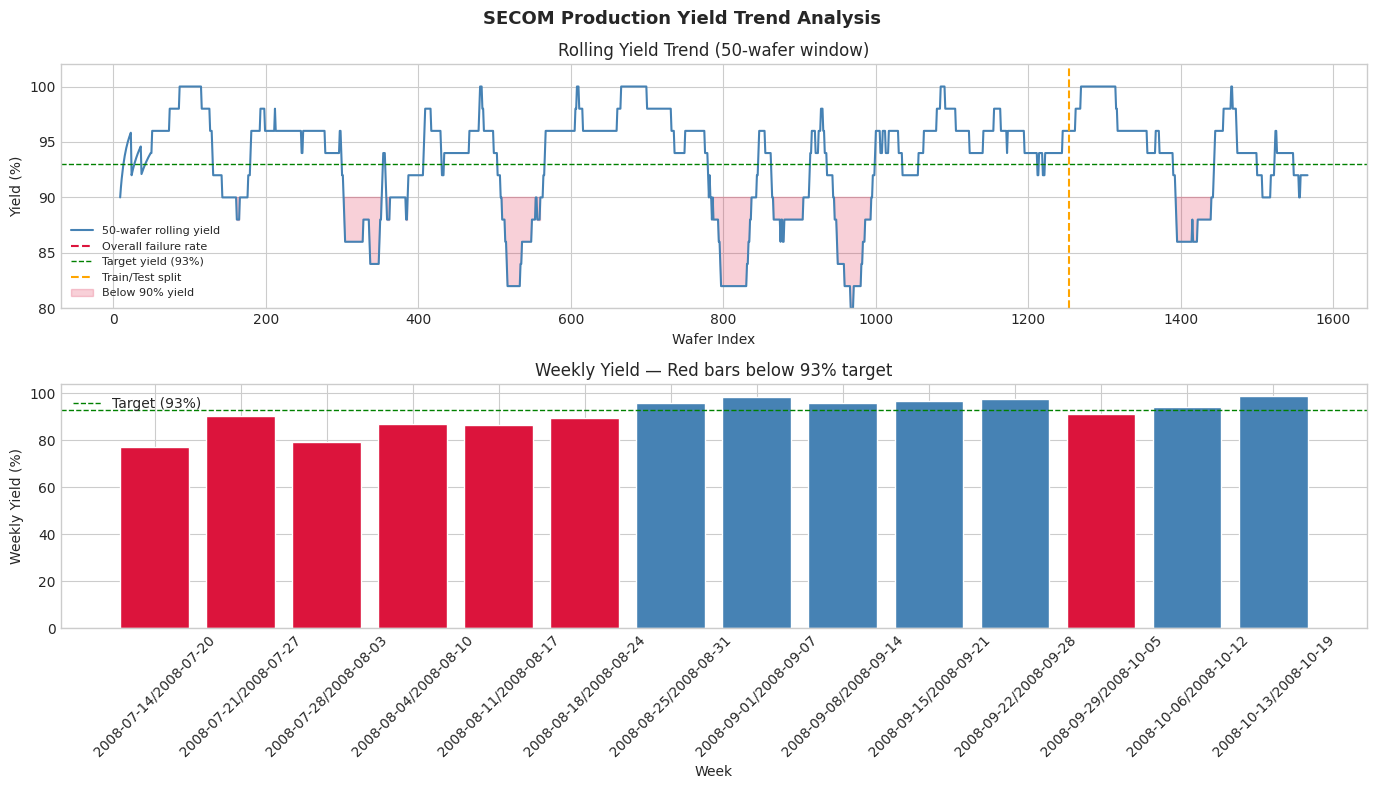

In [9]:
# Calculate rolling yield rate over time
# Using a 50-wafer rolling window to smooth day-to-day noise
df['failure'] = df['label']

# Rolling yield = percentage of passing wafers in last 50 wafers
df['rolling_yield'] = (
    1 - df['failure'].rolling(window=50, min_periods=10).mean()
) * 100

# Weekly yield aggregation
df['week'] = df['timestamp'].dt.to_period('W')
weekly_yield = df.groupby('week').agg(
    total_wafers  = ('failure', 'count'),
    total_failures = ('failure', 'sum')
).reset_index()
weekly_yield['yield_pct'] = (
    1 - weekly_yield['total_failures'] / weekly_yield['total_wafers']
) * 100
weekly_yield['week_str'] = weekly_yield['week'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: Rolling yield trend
axes[0].plot(df.index, df['rolling_yield'],
             color='steelblue', linewidth=1.5, label='50-wafer rolling yield')
axes[0].axhline(y=df['failure'].mean()*100,
                color='crimson', linestyle='--', label='Overall failure rate')
axes[0].axhline(y=93.0, color='green', linestyle='--',
                linewidth=1, label='Target yield (93%)')
axes[0].axvline(x=split_idx, color='orange', linestyle='--',
                linewidth=1.5, label='Train/Test split')
axes[0].fill_between(df.index, 90, df['rolling_yield'],
                     where=df['rolling_yield'] < 90,
                     color='crimson', alpha=0.2, label='Below 90% yield')
axes[0].set_ylabel('Yield (%)')
axes[0].set_xlabel('Wafer Index')
axes[0].set_title('Rolling Yield Trend (50-wafer window)')
axes[0].legend(fontsize=8)
axes[0].set_ylim(80, 102)

# Bottom: Weekly yield bar chart
colors = ['crimson' if y < 93 else 'steelblue'
          for y in weekly_yield['yield_pct']]
axes[1].bar(weekly_yield['week_str'], weekly_yield['yield_pct'],
            color=colors, edgecolor='white')
axes[1].axhline(y=93, color='green', linestyle='--',
                linewidth=1, label='Target (93%)')
axes[1].set_ylabel('Weekly Yield (%)')
axes[1].set_xlabel('Week')
axes[1].set_title('Weekly Yield — Red bars below 93% target')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('SECOM Production Yield Trend Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '/home/jupyter/secom-yield-optimization/data/processed/yield_trend.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

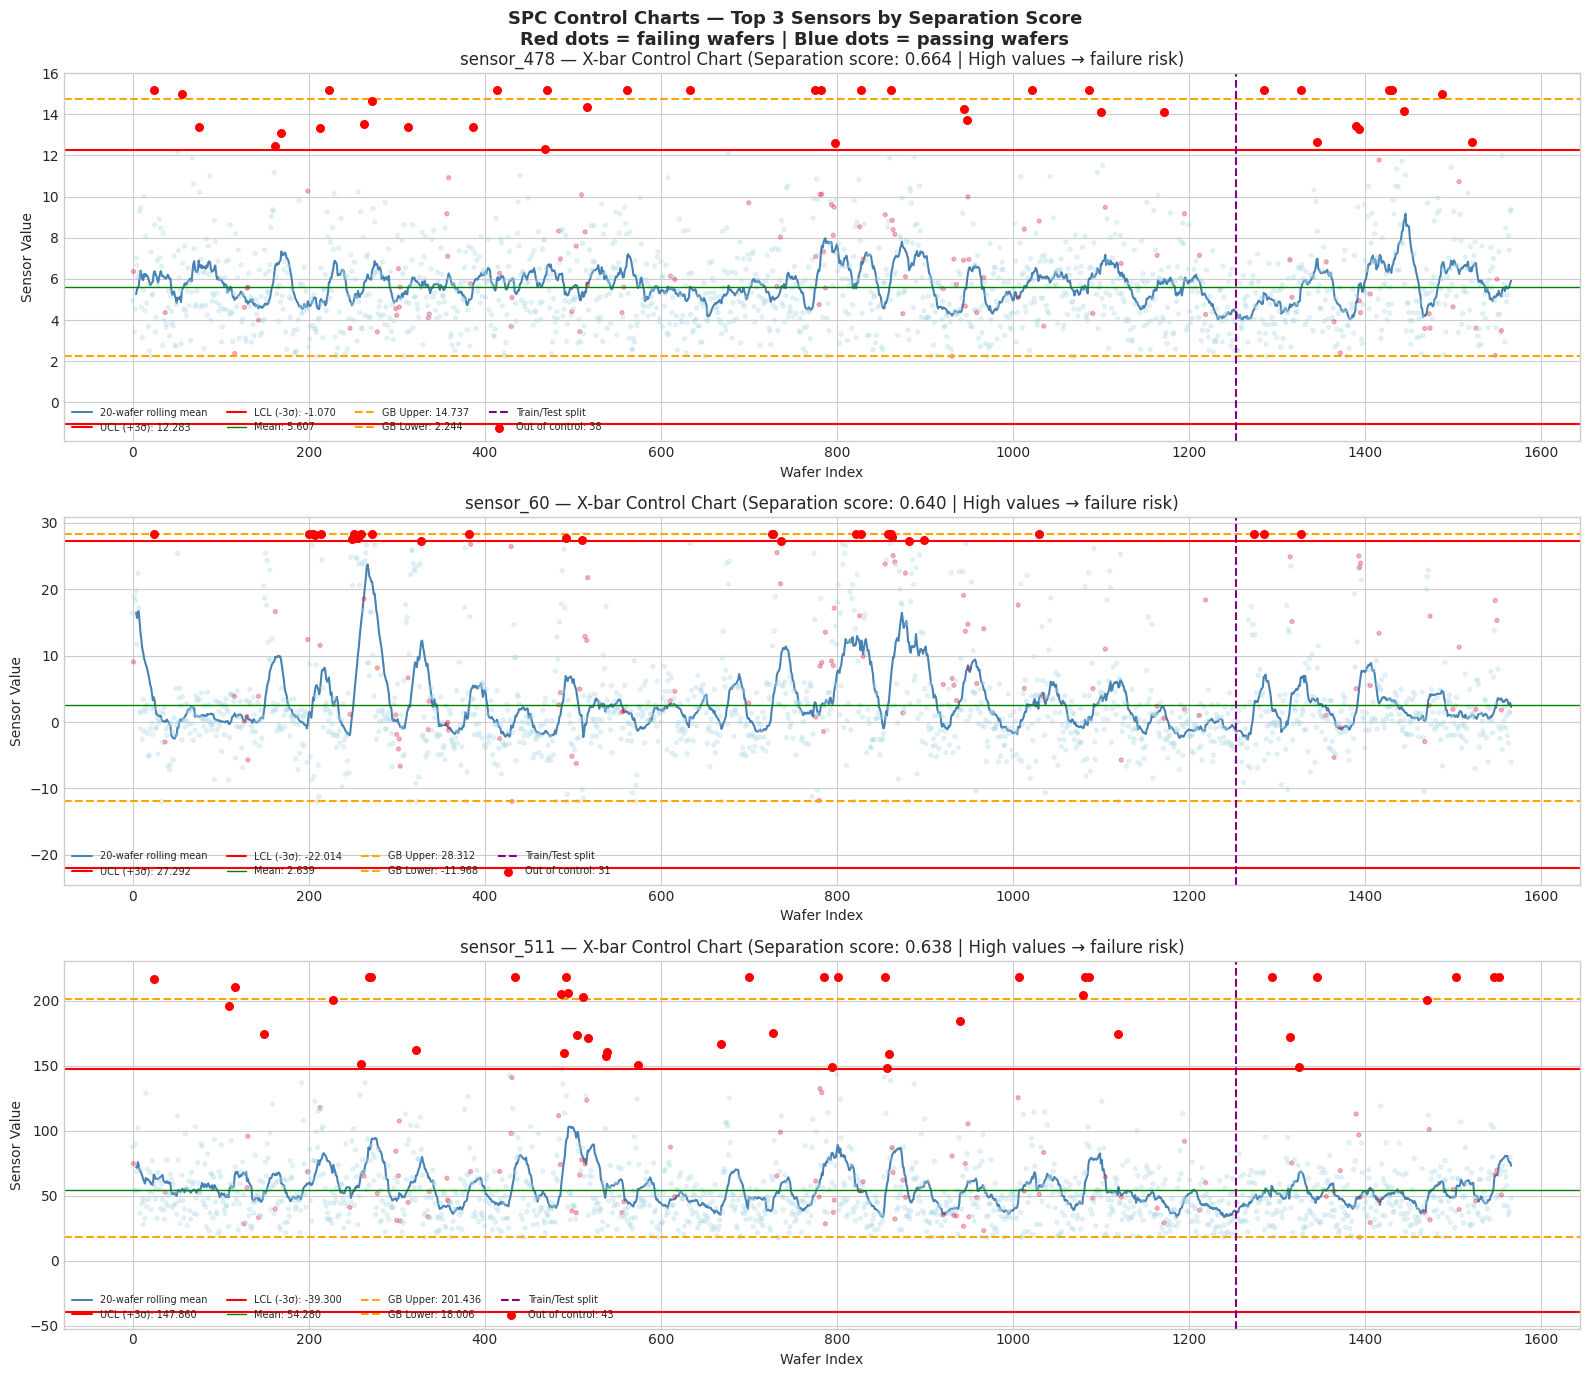

In [4]:
# Build X-bar control charts for top 3 sensors by separation score
# X-bar chart monitors the process mean over time
# Control limits set at ±3 sigma from training mean (Western Electric rules)

top3_sensors = gb_df.head(3)['sensor'].tolist()
train_df     = df.iloc[:split_idx]
test_df      = df.iloc[split_idx:]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for idx, sensor in enumerate(top3_sensors):
    ax = axes[idx]
    gb_row = gb_df[gb_df['sensor'] == sensor].iloc[0]

    # Calculate control limits from training data (passing wafers only)
    train_pass  = train_df[train_df['label'] == 0][sensor]
    proc_mean   = train_pass.mean()
    proc_std    = train_pass.std()
    ucl         = proc_mean + 3 * proc_std   # Upper Control Limit
    lcl         = proc_mean - 3 * proc_std   # Lower Control Limit

    # Rolling mean (20-wafer window) for smoothing
    rolling_mean = df[sensor].rolling(window=20, min_periods=5).mean()

    # Plot rolling mean
    ax.plot(df.index, rolling_mean,
            color='steelblue', linewidth=1.5, label='20-wafer rolling mean')

    # Plot individual wafer values (small dots)
    ax.scatter(df.index, df[sensor],
               c=['crimson' if l == 1 else 'lightblue' for l in df['label']],
               alpha=0.3, s=8, zorder=2)

    # Control limits (3-sigma)
    ax.axhline(y=ucl, color='red', linestyle='-',
               linewidth=1.5, label=f'UCL (+3σ): {ucl:.3f}')
    ax.axhline(y=lcl, color='red', linestyle='-',
               linewidth=1.5, label=f'LCL (-3σ): {lcl:.3f}')
    ax.axhline(y=proc_mean, color='green', linestyle='-',
               linewidth=1, label=f'Mean: {proc_mean:.3f}')

    # Guardband limits
    ax.axhline(y=gb_row['gb_upper'], color='orange', linestyle='--',
               linewidth=1.5, label=f'GB Upper: {gb_row["gb_upper"]:.3f}')
    ax.axhline(y=gb_row['gb_lower'], color='orange', linestyle='--',
               linewidth=1.5, label=f'GB Lower: {gb_row["gb_lower"]:.3f}')

    # Train/test split line
    ax.axvline(x=split_idx, color='purple', linestyle='--',
               linewidth=1.5, label='Train/Test split')

    # Highlight out-of-control points (beyond UCL or LCL)
    ooc_mask = (df[sensor] > ucl) | (df[sensor] < lcl)
    ax.scatter(df.index[ooc_mask], df[sensor][ooc_mask],
               color='red', s=30, zorder=5, label=f'Out of control: {ooc_mask.sum()}')

    ax.set_title(f'{sensor} — X-bar Control Chart '
                 f'(Separation score: {gb_row["separation_score"]:.3f} | '
                 f'{gb_row["risk_direction"]})')
    ax.set_xlabel('Wafer Index')
    ax.set_ylabel('Sensor Value')
    ax.legend(fontsize=7, ncol=4)

plt.suptitle('SPC Control Charts — Top 3 Sensors by Separation Score\n'
             'Red dots = failing wafers | Blue dots = passing wafers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '/home/jupyter/secom-yield-optimization/data/processed/spc_control_charts.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

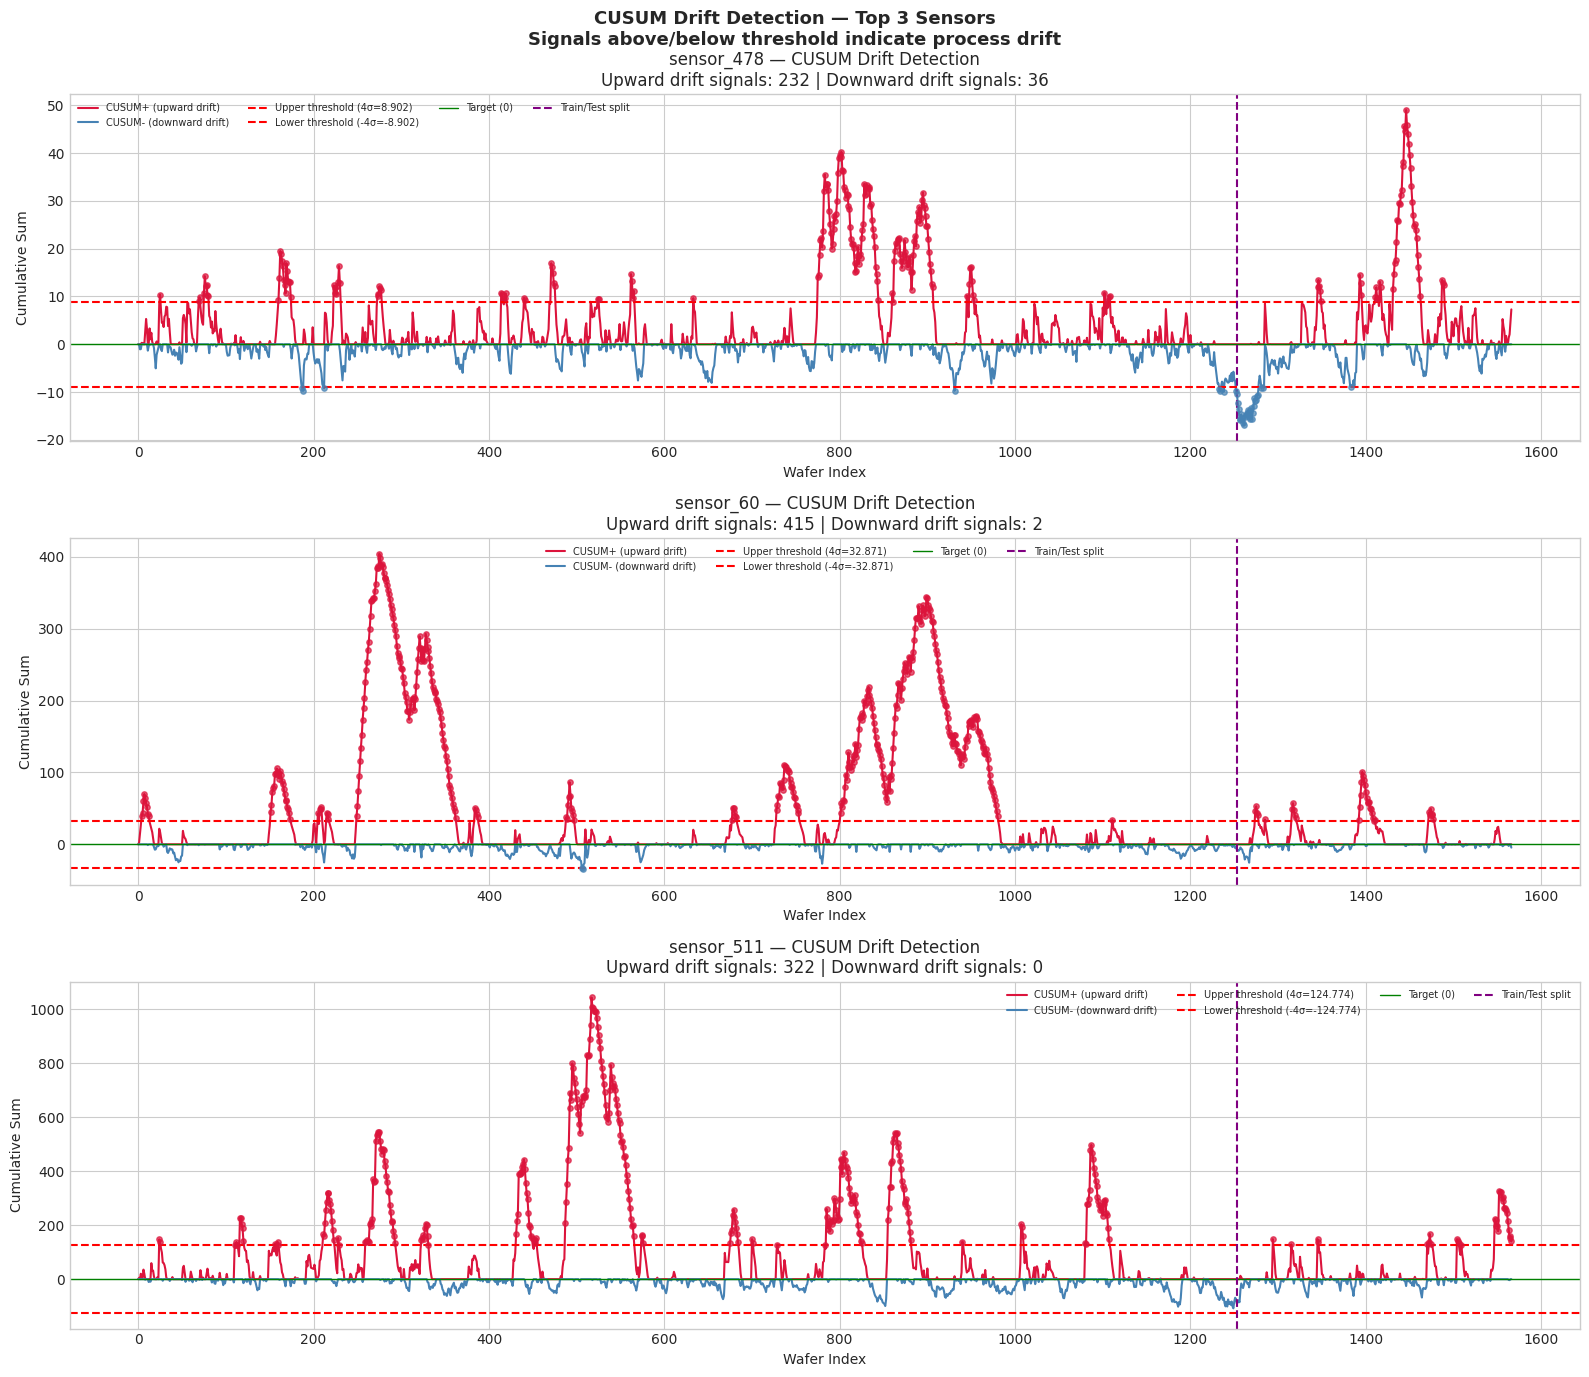

In [5]:
# CUSUM (Cumulative Sum) chart detects small persistent shifts
# in the process mean that X-bar charts might miss


top3_sensors = gb_df.head(3)['sensor'].tolist()
train_df     = df.iloc[:split_idx]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for idx, sensor in enumerate(top3_sensors):
    ax      = axes[idx]
    gb_row  = gb_df[gb_df['sensor'] == sensor].iloc[0]

    # Calculate process parameters from training pass wafers
    train_pass = train_df[train_df['label'] == 0][sensor]
    proc_mean  = train_pass.mean()
    proc_std   = train_pass.std()

    # CUSUM parameters
    # k = allowable slack = 0.5 sigma (standard choice)
    # h = decision threshold = 4 sigma (standard choice)
    # These are the Western Electric standard CUSUM parameters
    k = 0.5 * proc_std
    h = 4.0 * proc_std

    # Calculate CUSUM — upper and lower
    cusum_pos = np.zeros(len(df))  # detects upward shifts
    cusum_neg = np.zeros(len(df))  # detects downward shifts

    for i in range(1, len(df)):
        val = df[sensor].iloc[i]
        # Upper CUSUM: accumulates when values exceed mean + k
        cusum_pos[i] = max(0, cusum_pos[i-1] + (val - proc_mean) - k)
        # Lower CUSUM: accumulates when values fall below mean - k
        cusum_neg[i] = max(0, cusum_neg[i-1] - (val - proc_mean) - k)

    # Identify drift signal points
    drift_up   = cusum_pos > h
    drift_down = cusum_neg > h

    # Plot CUSUM
    ax.plot(df.index, cusum_pos, color='crimson', linewidth=1.5,
            label='CUSUM+ (upward drift)')
    ax.plot(df.index, -cusum_neg, color='steelblue', linewidth=1.5,
            label='CUSUM- (downward drift)')

    # Decision threshold lines
    ax.axhline(y=h,  color='red', linestyle='--', linewidth=1.5,
               label=f'Upper threshold (4σ={h:.3f})')
    ax.axhline(y=-h, color='red', linestyle='--', linewidth=1.5,
               label=f'Lower threshold (-4σ={-h:.3f})')
    ax.axhline(y=0,  color='green', linestyle='-', linewidth=1,
               label='Target (0)')

    # Mark drift signal points
    if drift_up.any():
        ax.scatter(df.index[drift_up], cusum_pos[drift_up],
                  color='crimson', s=15, zorder=5, alpha=0.7)
    if drift_down.any():
        ax.scatter(df.index[drift_down], -cusum_neg[drift_down],
                  color='steelblue', s=15, zorder=5, alpha=0.7)

    # Train/test split
    ax.axvline(x=split_idx, color='purple', linestyle='--',
               linewidth=1.5, label='Train/Test split')

    ax.set_title(f'{sensor} — CUSUM Drift Detection\n'
                 f'Upward drift signals: {drift_up.sum()} | '
                 f'Downward drift signals: {drift_down.sum()}')
    ax.set_xlabel('Wafer Index')
    ax.set_ylabel('Cumulative Sum')
    ax.legend(fontsize=7, ncol=4)

plt.suptitle('CUSUM Drift Detection — Top 3 Sensors\n'
             'Signals above/below threshold indicate process drift',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '/home/jupyter/secom-yield-optimization/data/processed/cusum_drift_detection.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [6]:
import subprocess


# Upload all Notebook 5 outputs to GCS
files = [
    'data/processed/yield_trend.png',
    'data/processed/spc_control_charts.png',
    'data/processed/cusum_drift_detection.png',
]

base   = '/home/jupyter/secom-yield-optimization/'
bucket = 'gs://secom-data-temi/'

for f in files:
    result = subprocess.run(
        ['gsutil', 'cp', base + f, bucket + f],
        capture_output=True, text=True
    )
    status = "Success!" if result.returncode == 0 else "Failed!"
    print(f"{status} {f}")

Success! data/processed/yield_trend.png
Success! data/processed/spc_control_charts.png
Success! data/processed/cusum_drift_detection.png
